In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile
stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup

Welcome to JupyROOT 6.28/10


In [2]:
from scipy.optimize import curve_fit
from uncertainties import ufloat
import math

def func(x, a, b):
    return a*x + b

def fit_logPulse(x, y, start, stop):
    popt, pcov = curve_fit(func, x[start:stop], y[start:stop])
    return popt[0], np.sqrt(np.diag(pcov))[0], popt[1], np.sqrt(np.diag(pcov))[1]

def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

In [3]:
DMCfiles = np.sort(glob.glob('/scratch/perry/Ge71_Kshell_50V_releaseV05-09_100kEvents/DMCOutput/R?/Ge71_Kshell_????????_000???.root'))

In [ ]:
g4dmcHits = CDataFrame('G4SimDir/g4dmcHits', DMCfiles)
EventNum = g4dmcHits.AsNumpy(['EventNum'])['EventNum']
X = g4dmcHits.AsNumpy(['X'])['X']*1e3
Y = g4dmcHits.AsNumpy(['Y'])['Y']*1e3
Z = g4dmcHits.AsNumpy(['Z'])['Z']*1e3

R = np.sqrt(X**2 + Y**2)

In [ ]:
_, X = zip(*sorted(zip(EventNum, X)))
_, Y = zip(*sorted(zip(EventNum, Y)))
_, Z = zip(*sorted(zip(EventNum, Z)))
_, R = zip(*sorted(zip(EventNum, R)))

In [3]:
RQfiles = np.sort(glob.glob("/scratch/perry/Ge71_Kshell_50V_releaseV05-09_100kEvents/Processed/R?/Unmerged/5125????_000000/Test_5125????_000000_F0???.root"))

In [4]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), RQfiles, friends = [[x+":rqDir/eventTree" for x in RQfiles]])

In [5]:
## Apply some basic data quality filters and get the RQs you're interested in
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(0), "PTOFamps>0"])

In [6]:
RQs = (["SeriesNumber", "PTOFamps", "EventNumber", "EventTime"])
df_rqs = df_filtered.AsNumpy(RQs + ['EventTriggerID'])

In [ ]:
for i in RQs:
    _, df_rqs[i] = zip(*sorted(zip(df_rqs['EventTriggerID'], df_rqs[i])))
    df_rqs[i] = np.array(df_rqs[i])

In [ ]:
ROOT.gStyle.SetPalette(ROOT.kCividis)

g = ROOT.TGraph2D(len(R), np.array(R, dtype='float64'), np.array(Z, dtype='float64'), np.array(df_rqs['PTOFamps'], dtype='float64')*1e6*10/4)
g.SetTitle(" ;R position [mm];Z position [mm];PTOFamps [#muA]")

g.GetXaxis().SetLabelSize(0.05)
g.GetYaxis().SetLabelSize(0.05)
g.GetXaxis().SetTitleSize(0.05)
g.GetYaxis().SetTitleSize(0.05)

# Draw the scatter plot with color ("COLZ" = color palette + z-axis)
# Draw the histogram
c = ROOT.TCanvas("c", "Canvas", 700, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.15)
c.SetTopMargin(0.05)
g.SetNpx(100)
g.SetNpy(100)
g.Draw("COLZ")  # "P" = points, "COLZ" = color map + z axis
c.Draw()

In [ ]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 30
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", f";Amplitude [#muA];Count / ({bindiff} #muA)", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps']*1e6*10/4

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)
h.SetLineWidth(3)  # Thicker line
h.SetLineColor(ROOT.kBlue)
    
h.SetMinimum(0)
#h.SetMaximum(700)  # Adjust based on your data
h.GetXaxis().SetLabelSize(0.05)
h.GetYaxis().SetLabelSize(0.05)
h.GetXaxis().SetTitleSize(0.05)
h.GetYaxis().SetTitleSize(0.05)
#h.GetXaxis().SetRangeUser(-2, 35)

# Draw the histogram
c = ROOT.TCanvas("c", "Canvas", 700, 600)
c.SetLeftMargin(0.20)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.05)
h.Draw()
c.Draw()

In [ ]:
ROOT.gStyle.SetOptStat(0)
bins_start = 0
bins_end = 30
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 2)

c = ROOT.TCanvas("c", "Canvas", 700, 600)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h1 = ROOT.TH1F("h", f";Amplitude [#muA];Count / ({bindiff} #muA)", nbins, bins_start, bins_end)
data1 = np.array(df_rqs['PTOFamps'], dtype='float64')*1e6*10/4

for value in data1:
    h1.Fill(value)
h1.SetLineWidth(3)
h1.SetLineColor(ROOT.kBlue)
    
#h.SetMinimum(0)
#h.SetMaximum(3000)
h1.GetXaxis().SetLabelSize(0.05)
h1.GetYaxis().SetLabelSize(0.05)
h1.GetXaxis().SetTitleSize(0.05)
h1.GetYaxis().SetTitleSize(0.05)
#h1.GetXaxis().SetRangeUser(-4, 12)
h1.Draw()

# Create the inset histogram (for example, zoomed-in portion)
inset_hist = ROOT.TH1F("inset_hist", ";Amplitude [#muA];Count / (0.12 #muA)", 50, 24, 30)
for value in data1:
    inset_hist.Fill(value)
inset_hist.SetLineWidth(3)
# Create a small inset pad (TPad)
# Define the position and size of the inset as (x1, y1, x2, y2), where values are between 0 and 1
inset_pad = ROOT.TPad("inset_pad", "Inset Pad", 0.25, 0.4, 0.73, 0.90)
#inset_pad.SetBorderSize(2)  # Optional: Set the border size of the inset
inset_pad.SetFillColor(0)   # Set background color of inset (0 means transparent)
inset_pad.Draw()  # Draw the inset pad on the main canvas
inset_pad.cd()  # Switch to the inset pad

# Draw the inset histogram (zoomed-in version)
inset_hist.SetLineColor(ROOT.kBlue)
inset_hist.GetXaxis().SetLabelSize(0.05)
inset_hist.GetYaxis().SetLabelSize(0.05)
inset_hist.GetXaxis().SetTitleSize(0.05)
inset_hist.GetYaxis().SetTitleSize(0.05)
inset_hist.Draw()

# Optionally, add a box around the inset plot to highlight it
inset_pad.SetFrameBorderSize(3)
inset_pad.SetFrameBorderMode(1)
# Adjust the margins of the inset pad
inset_pad.SetLeftMargin(0.2)    # Reduce left margin
inset_pad.SetRightMargin(0.01)   # Reduce right margin
inset_pad.SetTopMargin(0.01)     # Reduce top margin
inset_pad.SetBottomMargin(0.2)  # Reduce bottom margin

# Draw a border around the inset axis (optional)
#inset_pad.SetFrameFillColor(ROOT.kWhite)  # Set background of inset border
#inset_pad.SetFrameLineColor(ROOT.kBlack)


c.SetLeftMargin(0.2)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.Update()
c.Draw()

In [ ]:
ROOT.gStyle.SetOptStat(0)
bins_start = 24
bins_end = 30
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", f";Amplitude [#muA];Count / ({bindiff} #muA)", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps']*1e6*10/4

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)
h.SetLineWidth(3)  # Thicker line
h.SetLineColor(ROOT.kBlue)
    
h.SetMinimum(0)
#h.SetMaximum(700)  # Adjust based on your data
h.GetXaxis().SetLabelSize(0.05)
h.GetYaxis().SetLabelSize(0.05)
h.GetXaxis().SetTitleSize(0.05)
h.GetYaxis().SetTitleSize(0.05)
#h.GetXaxis().SetRangeUser(-2, 35)

# Draw the histogram
c = ROOT.TCanvas("c", "Canvas", 700, 600)
c.SetLeftMargin(0.20)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.05)
h.Draw()
c.Draw()

 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu2         2.73000e+01  2.70000e-01    2.73000e+01  3.00000e+01
 MINUIT WARNING IN PARAM DEF
 ============== STARTING VALUE IS AT LIMIT.
 MINUIT WARNING IN PARAMETR
 ============== VARIABLE1 IS AT ITS LOWER ALLOWED LIMIT.
 MINUIT WARNING IN PARAMETR
 ============== VARIABLE1 BROUGHT BACK INSIDE LIMITS.
     2 #sigma2      3.00000e-01  9.00000e-02    1.00000e-01  1.00000e+00
     3 c           -2.00000e+01  1.00000e+01   -1.00000e+02  0.00000e+00
     4 c1           4.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     5 c2           4.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     6 delta        4.00000e+00  9.90000e-01    1.00000e-01  1.00000e+01
     7 gamma       -2.00000e+00  2.00000e+00   -1.00000e+01  1.00000e+01
     8 lambda       3.00000e-01  9.00000e-02    1.00000e-01  1.000

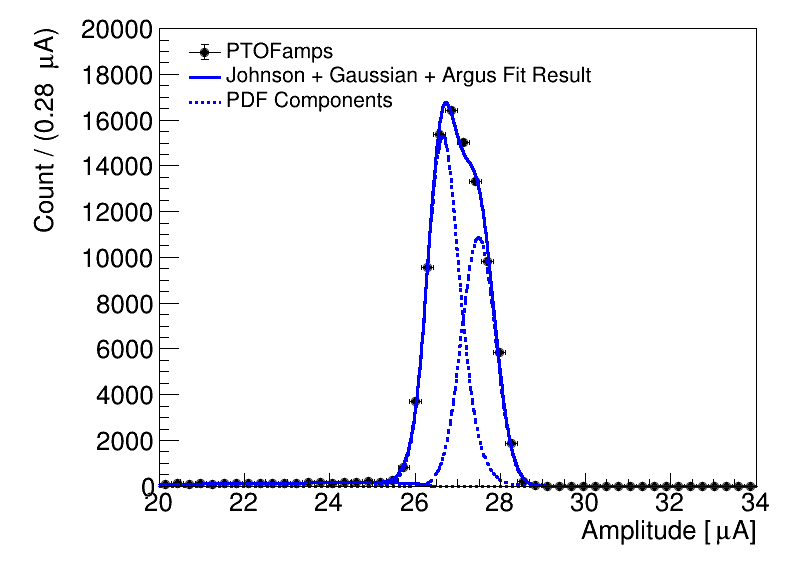

In [7]:
ROOT.gStyle.SetOptStat(0)
bins_start = 20
bins_end = 34
nbins = 50
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", f";Amplitude [#muA];Count / ({bindiff} #muA)", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps']*1e6*10/4

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)

x = ROOT.RooRealVar("x", "x", bins_start, bins_end)  # use your histogram's x range

# Parameters
xi     = ROOT.RooRealVar("xi", "Location", 26.82, 26, 27.2)      # shifts the center
lambda_ = ROOT.RooRealVar("lambda", "Scale", 0.3, 0.1, 1)  # like sigma
gamma  = ROOT.RooRealVar("gamma", "Skew", -2.0, -10, 10)      # skewness
delta  = ROOT.RooRealVar("delta", "Tail", 4.0, 0.1, 10.0)     # tail heaviness


# JohnsonSU PDF
johnsu = ROOT.RooJohnson("johnsu", "Johnson SU", x, xi, lambda_, gamma, delta)

# Parameters
mean_2 = ROOT.RooRealVar("#mu2", "#mu", 27.3, 27.3, 30)
sigma_2 = ROOT.RooRealVar("#sigma2", "#sigma", 0.3, 0.1, 1)

# Argus background (left-side tail)
m0   = ROOT.RooRealVar("m0", "Endpoint", 26.82, 25, 27.2)  # same as Gaussian mean
c    = ROOT.RooRealVar("c", "Curvature", -20.0, -100.0, 0.0)
argus = ROOT.RooArgusBG("argus", "Argus Tail", x, m0, c)

g2 = ROOT.RooGaussian("g2", "#g2", x, mean_2, sigma_2)

# Weight of distributions
frac1 = ROOT.RooRealVar("c1", "#c", 0.4, 0.0, 1.0)
frac2 = ROOT.RooRealVar("c2", "#c", 0.4, 0.0, 1.0)
frac3 = ROOT.RooRealVar("c2", "#c", 0.2, 0.0, 1.0)

# Convert numpy array into RooFit object
model = ROOT.RooAddPdf("model", "model", ROOT.RooArgList(johnsu, g2, argus), ROOT.RooArgList(frac1, frac2))
data = ROOT.RooDataHist("data", "binned data", ROOT.RooArgList(x), h)

#fit_result = model.fitTo(data)  # binned by default for RooDataHist
nll = model.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = x.frame(ROOT.RooFit.Title(" "))
# Change axis labels
frame.GetXaxis().SetTitle("Amplitude [#muA]")
frame.GetYaxis().SetTitle(f"Count / ({bindiff} #muA)")
frame.GetXaxis().SetLabelSize(0.05)
frame.GetYaxis().SetLabelSize(0.05)
frame.GetXaxis().SetTitleSize(0.05)
frame.GetYaxis().SetTitleSize(0.05)

data.plotOn(frame, ROOT.RooFit.Name("PTOFamps"))
model.plotOn(frame, ROOT.RooFit.Name(f"Johnson + Gaussian + Argus Fit Result"))
model.plotOn(frame, ROOT.RooFit.Components("argus"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("PDF Components"))
model.plotOn(frame, ROOT.RooFit.Components("johnsu"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
model.plotOn(frame, ROOT.RooFit.Components("g2"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
#model.plotOn(frame, ROOT.RooFit.Components("g3"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))

# Create legend
legend = ROOT.TLegend(0.23, 0.8, 0.45, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)

# Add entries by retrieving plotted objects by name
legend.AddEntry(frame.findObject("PTOFamps"),  "PTOFamps", "lep")
legend.AddEntry(frame.findObject(f"Johnson + Gaussian + Argus Fit Result"), f"Johnson + Gaussian + Argus Fit Result", "l")
legend.AddEntry(frame.findObject("PDF Components"), "PDF Components", "l")
legend.SetTextSize(0.04)

frame.SetMinimum(0)
frame.SetMaximum(20000)  # Adjust based on your data
#frame.SetMaximum(250)  # Adjust based on your data
    
c = ROOT.TCanvas("c", "Fit Canvas", 800, 600)
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.05)
c.SetTopMargin(0.05)
frame.Draw()
legend.Draw()
c.Draw()

In [8]:
K_peak_data = df_rqs['PTOFamps'][(df_rqs['PTOFamps']*10/4 >= 20e-6) & (df_rqs['PTOFamps']*10/4 <= 34e-6)] * 1e6 * 10/4

In [9]:
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(K_peak_data))
sum_frac1_frac2 = ROOT.RooFormulaVar("sum_c1_c2", "@0 + @1", ROOT.RooArgList(frac1, frac2))
signal = ROOT.RooProduct("event yield", "nevent * (frac1 + frac2)", ROOT.RooArgList(nevent, sum_frac1_frac2))

print(f'The number of events in the peak is {signal.getVal():.5f} with error {signal.getPropagatedError(fit_result):.5f}')

The number of events in the peak is 91901.20283 with error 60.90343


In [10]:
nevent = ROOT.RooRealVar("#nevent", "#number of fitted events", len(K_peak_data))
one_minus_sum_frac1_frac2 = ROOT.RooFormulaVar("#one_minus_sum_c1_c2", "1 - @0 - @1", ROOT.RooArgList(frac1, frac2))
bkg = ROOT.RooProduct("event yield", "nevent * (1 - c1 - c2)", ROOT.RooArgList(nevent, one_minus_sum_frac1_frac2))

print(f'The number of events in the reduced amplitude spectrum is {bkg.getVal():.5f} with error {bkg.getPropagatedError(fit_result):.5f}')

The number of events in the reduced amplitude spectrum is 2766.79717 with error 60.90343


In [11]:
91758 / 2767

33.16154680159017

In [12]:
np.sqrt((1/2767 * 64)**2 + (91758/2767**2 * 61)**2)

0.7314298996887522